## **CNN - American Sign Language (ASL)**

## **Dataset Link:**

https://www.kaggle.com/datasets/ayuraj/asl-dataset

In [ ]:
# Download Dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayuraj/asl-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-dataset' dataset.
Path to dataset files: /kaggle/input/asl-dataset


In [ ]:
import os
import shutil
import random

In [ ]:
# original dataset path
source_dir = "/kaggle/input/asl-dataset/asl_dataset"

# new split dataset path
base_dir = "/content/asl_split"

In [ ]:
# create folders
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(base_dir, split), exist_ok=True)

In [ ]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [ ]:
["train": "im1.png",im2,im3,im4,im5]

In [ ]:
# loop over each class
for class_name in os.listdir(source_dir):
    if class_name != "asl_dataset":
      class_path = os.path.join(source_dir, class_name)

      images = os.listdir(class_path)
      random.shuffle(images)

      total = len(images)
      train_end = int(train_ratio * total)
      val_end = train_end + int(val_ratio * total)

      splits = {
          "train": images[:train_end],
          "val": images[train_end:val_end],
          "test": images[val_end:]
      }

      for split, split_images in splits.items():
        split_class_dir = os.path.join(base_dir, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy(src, dst)

print("Dataset successfully split into train/val/test folders.")

Dataset successfully split into train/val/test folders.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
img_size = (64, 64)

In [ ]:
# Data augmentaion
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    brightness_range=[0.5, 1.5],
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    "/content/asl_split/train",
    target_size=img_size,
    class_mode="categorical",
    subset="training"
)

val_data = test_datagen.flow_from_directory(
    "/content/asl_split/val",
    target_size=img_size,
    class_mode="categorical",
)

test_data = test_datagen.flow_from_directory(
    "/content/asl_split/test",
    target_size=img_size,
    class_mode="categorical",
)

Found 1760 images belonging to 36 classes.
Found 359 images belonging to 36 classes.
Found 396 images belonging to 36 classes.


In [ ]:
train_data.class_indices

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9,
 'a': 10,
 'b': 11,
 'c': 12,
 'd': 13,
 'e': 14,
 'f': 15,
 'g': 16,
 'h': 17,
 'i': 18,
 'j': 19,
 'k': 20,
 'l': 21,
 'm': 22,
 'n': 23,
 'o': 24,
 'p': 25,
 'q': 26,
 'r': 27,
 's': 28,
 't': 29,
 'u': 30,
 'v': 31,
 'w': 32,
 'x': 33,
 'y': 34,
 'z': 35}

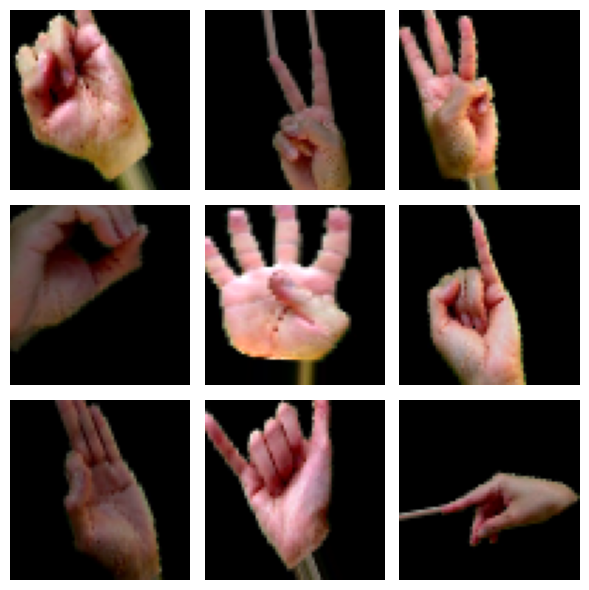

In [ ]:
import matplotlib.pyplot as plt

# get one batch
images, labels = next(train_data)

plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.0269 - loss: 3.6019 - val_accuracy: 0.0279 - val_loss: 3.5767
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.0273 - loss: 3.5758 - val_accuracy: 0.0836 - val_loss: 3.3958
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.0435 - loss: 3.4793 - val_accuracy: 0.1699 - val_loss: 3.1204
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.0808 - loss: 3.3037 - val_accuracy: 0.2423 - val_loss: 2.6642
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.1063 - loss: 3.0716 - val_accuracy: 0.2869 - val_loss: 2.4444
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.1294 - loss: 2.9377 - val_accuracy: 0.3175 - val_loss: 2.1910
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.1664 - loss: 2.7850 - val_accuracy: 0.3120 - val_loss: 2.0164
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.1611 - loss: 2.6684 - val_accuracy: 0.3092 - val_loss: 

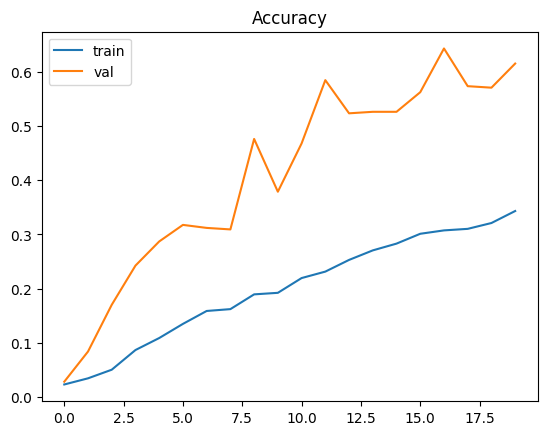

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()
plt.show()

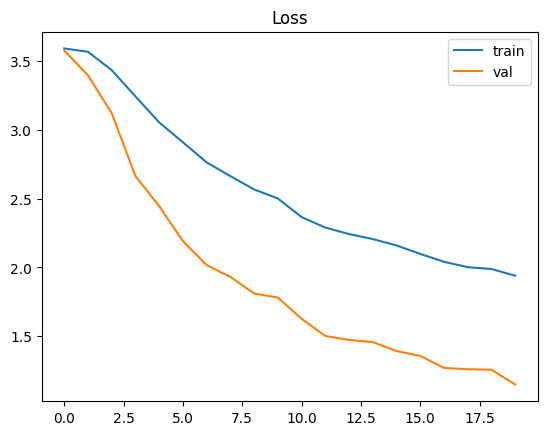

In [ ]:
# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()
plt.show()

In [ ]:
model.save('ASL_model.h5')

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
from PIL import Image
import numpy as np

In [ ]:
model = load_model('/content/ASL_model.h5')

In [ ]:
img = Image.open('/content/webcam1.jpg')

In [ ]:
img = Image.open('/content/webcam1.jpg')
img = np.array(img)
img = img/255
img = np.expand_dims(img, axis=0)

In [ ]:
img.shape

(1, 64, 64, 3)

In [ ]:
pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [ ]:
pred


array([[3.47793475e-02, 7.63901880e-06, 1.38323321e-05, 3.68321314e-02,
        2.47561708e-02, 5.45608997e-02, 9.67000669e-04, 3.68881896e-02,
        1.95619643e-01, 1.06423222e-01, 6.69219997e-03, 7.05003878e-03,
        1.00582674e-01, 3.15271564e-06, 8.41780799e-04, 9.15326253e-02,
        2.29539364e-06, 1.09218818e-05, 1.06301829e-02, 4.80489992e-03,
        2.03827280e-03, 8.36896419e-04, 3.12813354e-04, 3.69604095e-05,
        1.91134643e-02, 3.76908247e-05, 2.45296193e-04, 1.39377626e-05,
        1.80349205e-04, 8.55182880e-04, 1.58375806e-05, 7.43546843e-05,
        2.90592754e-04, 8.48028692e-04, 2.62101322e-01, 1.98720315e-07]],
      dtype=float32)

In [ ]:
classes = [
    '0','1','2','3','4','5','6','7','8','9',
    'a','b','c','d','e','f','g','h','i','j',
    'k','l','m','n','o','p','q','r','s','t',
    'u','v','w','x','y','z'
]

In [ ]:
np.argmax(pred, axis=1)

array([34])

In [ ]:
classes[np.argmax(pred, axis=1)[0]]

'y'